**Proyecto 1- Parte final (Core)**

Proyecto 1: Análisis y Predicción de Ventas en una Tienda de Retail

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [3]:
# retail-sales-analysis
import numpy as np
import pandas as pd
df = pd.read_csv('/content/retail_sales_dataset.csv')

# 2.2. Primeras filas (vista rápida)
df.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


**3. Exploración Inicial de los Datos**

3.1. Muestra las últimas 5 filas del DataFrame.

3.2. Utiliza el método info() para obtener información general sobre el DataFrame, incluyendo el número de entradas, nombres de las columnas, tipos de datos y memoria utilizada.

3.3. Genera estadísticas descriptivas del DataFrame utilizando el método describe().

In [4]:
# 3.1. Muestra las últimas 5 filas del DataFrame.
print("Últimas filas del DataFrame:")
print(df.tail(5))

Últimas filas del DataFrame:
     Transaction ID        Date Customer ID  Gender  Age Product Category  \
995             996  2023-05-16     CUST996    Male   62         Clothing   
996             997  2023-11-17     CUST997    Male   52           Beauty   
997             998  2023-10-29     CUST998  Female   23           Beauty   
998             999  2023-12-05     CUST999  Female   36      Electronics   
999            1000  2023-04-12    CUST1000    Male   47      Electronics   

     Quantity  Price per Unit  Total Amount  
995         1              50            50  
996         3              30            90  
997         4              25           100  
998         3              50           150  
999         4              30           120  


In [5]:
# 3.2. Obtener información general sobre el DataFrame
print("Información del DataFrame:")
print(df.info())

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
None


In [6]:
# 3.3. Generar estadísticas descriptivas
print("Estadísticas descriptivas del DataFrame:")
print(df.describe())

Estadísticas descriptivas del DataFrame:
       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.00000     1.000000       30.000000     60.000000
50%        500.500000    42.00000     3.000000       50.000000    135.000000
75%        750.250000    53.00000     4.000000      300.000000    900.000000
max       1000.000000    64.00000     4.000000      500.000000   2000.000000


**4. Inspección de los Datos**

4.1. Inspecciona los tipos de datos de cada columna utilizando el atributo dtypes.

4.2. Cuenta los valores únicos en la columna Producto utilizando el método value_counts().

4.3. Muestra todos los valores únicos en la columna Tienda utilizando el método unique().


In [7]:
# 4.1. Inspeccionar los tipos de datos de las columnas
print("Tipos de datos de las columnas:")
print(df.dtypes)

Tipos de datos de las columnas:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


In [8]:
# 4.2. Contar valores únicos en una columna específica
print("Conteo de valores únicos en la columna 'Product Category':")
print(df['Product Category'].value_counts())

Conteo de valores únicos en la columna 'Product Category':
Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64


In [9]:
# 4.3. Obtener valores únicos en una columna específica
# El dataset no contiene una columna "Tienda", por lo que se utilizó la variable "Product Category"
print("Valores únicos en la columna 'Product Category':")
print(df['Product Category'].unique())

Valores únicos en la columna 'Product Category':
['Beauty' 'Clothing' 'Electronics']


**5. Filtrado de Datos**

5.1. Filtra el DataFrame para mostrar solo las filas donde las ventas (Ventas) sean mayores a 50.

5.2. Filtra el DataFrame para mostrar solo las filas donde el precio (Precio) sea menor a 0.5.

5.3. Utilizando el método query(), filtra el DataFrame para mostrar las filas donde el producto sea Manzanas y las ventas sean mayores a 30.

In [10]:
# 5.1. mostrar solo las filas donde las ventas (Ventas) sean mayores a 50.
ventas_mayores_50 = df[df['Total Amount'] > 50]
print(ventas_mayores_50)

     Transaction ID        Date Customer ID  Gender  Age Product Category  \
0                 1  2023-11-24     CUST001    Male   34           Beauty   
1                 2  2023-02-27     CUST002  Female   26         Clothing   
3                 4  2023-05-21     CUST004    Male   37         Clothing   
4                 5  2023-05-06     CUST005    Male   30           Beauty   
7                 8  2023-02-22     CUST008    Male   30      Electronics   
..              ...         ...         ...     ...  ...              ...   
993             994  2023-12-18     CUST994  Female   51           Beauty   
996             997  2023-11-17     CUST997    Male   52           Beauty   
997             998  2023-10-29     CUST998  Female   23           Beauty   
998             999  2023-12-05     CUST999  Female   36      Electronics   
999            1000  2023-04-12    CUST1000    Male   47      Electronics   

     Quantity  Price per Unit  Total Amount  
0           3              50

In [11]:
# 5.2. Filtra el DataFrame para mostrar solo las filas donde el precio (Precio) sea menor a 0.5.
precio_menor_05 = df[df['Price per Unit'] < 0.5]
print(precio_menor_05)

# Al aplicar el filtro para identificar precios menores a 0.5,
# el resultado fue un DataFrame vacío. Esto se debe a que la columna "Price per Unit"
# contiene valores enteros mayores a ese umbral, por lo que no existen registros que cumplan la condición.
print(df['Price per Unit'].min())

Empty DataFrame
Columns: [Transaction ID, Date, Customer ID, Gender, Age, Product Category, Quantity, Price per Unit, Total Amount]
Index: []
25


In [12]:
# 5.3. Utilizando el método query(), filtra el DataFrame para mostrar las filas donde el producto sea Manzanas y las ventas sean mayorer a 30.
print(df['Product Category'].unique())
resultado = df.query("`Total Amount` > 30")
print(resultado.head())

# Se utilizó el método query() para filtrar los datos, seleccionando los registros donde la categoría del producto
#corresponde a "Manzanas", el cual no existe en la base, por lo que se filtro por monto total de ventas es mayor a 30.

['Beauty' 'Clothing' 'Electronics']
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   
6               7  2023-03-13     CUST007    Male   46         Clothing   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
3         1             500           500  
4         2              50           100  
6         2              25            50  


**6. Slicing de Datos**

6.1. Selecciona y muestra solo las columnas Producto y Ventas del DataFrame.

6.2. Utilizando loc[], selecciona y muestra las filas de la 5 a la 10 (inclusive) y las columnas Producto y Tienda.

6.3. Utilizando iloc[], selecciona y muestra las primeras 5 filas y las primeras 3 columnas del DataFrame.


In [13]:
# 6.1. Seleccionar columnas Producto y Ventas
columnas_seleccionadas = df[['Product Category', 'Total Amount']]
print(columnas_seleccionadas.head())

  Product Category  Total Amount
0           Beauty           150
1         Clothing          1000
2      Electronics            30
3         Clothing           500
4           Beauty           100


In [14]:
# 6.2. Seleccionar filas de la 5 a la 10 y columnas Producto y Tienda
filas_columnas = df.loc[5:10, ['Product Category', 'Gender']]
print(filas_columnas)

   Product Category  Gender
5            Beauty  Female
6          Clothing    Male
7       Electronics    Male
8       Electronics    Male
9          Clothing  Female
10         Clothing    Male


In [15]:
# 6.3. Seleccionar las primeras 5 filas y primeras 3 columnas
primeras_filas_columnas = df.iloc[0:5, 0:3]
print(primeras_filas_columnas)

   Transaction ID        Date Customer ID
0               1  2023-11-24     CUST001
1               2  2023-02-27     CUST002
2               3  2023-01-13     CUST003
3               4  2023-05-21     CUST004
4               5  2023-05-06     CUST005


**Proyecto  I – Parte III**

**1. Transformación de Datos**

1.1. Crea nuevas columnas: Basándonos en los datos existentes, crea nuevas columnas que sean útiles para el análisis. Por ejemplo, calcula el ingreso total por venta y normaliza las ventas.

1.2. Clasifica los datos: Crea una columna que clasifique las ventas en categorías significativas (e.g., ‘Alta’, ‘Media’, ‘Baja’).

In [16]:

# 1.1.1. Crear columna de ingreso total por venta
df['Ingreso_Total'] = df['Quantity'] * df['Price per Unit']
print(df[['Quantity', 'Price per Unit', 'Ingreso_Total']].head())

# 1.1.2. Normalizar ventas
df['Ventas_Normalizadas'] = (
    (df['Total Amount'] - df['Total Amount'].min()) /
    (df['Total Amount'].max() - df['Total Amount'].min())
)
print(df[['Total Amount', 'Ventas_Normalizadas']].head())

   Quantity  Price per Unit  Ingreso_Total
0         3              50            150
1         2             500           1000
2         1              30             30
3         1             500            500
4         2              50            100
   Total Amount  Ventas_Normalizadas
0           150             0.063291
1          1000             0.493671
2            30             0.002532
3           500             0.240506
4           100             0.037975


In [17]:
# 1.2. Función para clasificar ventas
def clasificar_ventas(valor):

    if valor < 200:
        return 'Baja'

    elif valor < 600:
        return 'Media'

    else:
        return 'Alta'

# Crear nueva columna
df['Categoria_Ventas'] = df['Total Amount'].apply(clasificar_ventas)
print(df[['Total Amount', 'Categoria_Ventas']].head())

   Total Amount Categoria_Ventas
0           150             Baja
1          1000             Alta
2            30             Baja
3           500            Media
4           100             Baja


**2. Agrupación y Agregación**

2.1. Agrupación por múltiples columnas: Realiza agrupaciones por categorías como producto y tienda, producto y mes, etc.

2.2. Aplicar funciones de agregación: Utiliza funciones como sum, mean, count, min, max, std, y var para obtener estadísticas descriptivas de cada grupo.

In [18]:
# 2.1. Agrupar por categoría de producto y género
agrupacion = df.groupby(
    ['Product Category', 'Gender']
)['Total Amount'].sum()
print(agrupacion)

Product Category  Gender
Beauty            Female    74830
                  Male      68685
Clothing          Female    81275
                  Male      74305
Electronics       Female    76735
                  Male      80170
Name: Total Amount, dtype: int64


In [19]:
# 2.2. Agrupar por categoría de producto
estadisticas = df.groupby(
    'Product Category'
)['Total Amount'].agg([
    'sum',
    'mean',
    'count',
    'min',
    'max',
    'std',
    'var'
])
print(estadisticas)

                     sum        mean  count  min   max         std  \
Product Category                                                     
Beauty            143515  467.475570    307   25  2000  563.612788   
Clothing          155580  443.247863    351   25  2000  550.695917   
Electronics       156905  458.786550    342   25  2000  567.540150   

                            var  
Product Category                 
Beauty            317659.374401  
Clothing          303265.992674  
Electronics       322101.822341  


**3. Análisis Personalizado con apply**

3.1. Función personalizada: Aplica funciones personalizadas para realizar análisis específicos que no se pueden lograr con las funciones de agregación estándar.

Ejemplo de uso avanzado: Calcula la desviación de cada venta respecto a la media de su grupo.

In [20]:
# 3.1. Calcular promedio por categoría
promedio_categoria = df.groupby(
    'Product Category'
)['Total Amount'].transform('mean')
print(promedio_categoria.head())


0    467.475570
1    443.247863
2    458.786550
3    443.247863
4    467.475570
Name: Total Amount, dtype: float64


**4. Documentación**

4.1. Comentarios claros: Documenta claramente cada paso del análisis, explicando qué se hizo y por qué se hizo.

4.2. Código legible: Asegúrate de que el código sea legible y esté bien comentado.

4.1. A partir del análisis exploratorio realizado sobre el dataset de ventas retail, fue posible comprender mejor el comportamiento de las ventas y las características principales de los clientes y productos.
Además, las agrupaciones permitieron analizar patrones de ventas según distintas variables, como categoría de producto y género.

4.2. El código fue organizado en secciones utilizando títulos y comentarios descriptivos, manteniendo nombres de variables claros y fáciles de interpretar.

**Parte IV: Análisis Exploratorio de Datos (EDA) y Visualización**

En esta cuarta parte del proyecto, aplicaremos técnicas avanzadas de análisis exploratorio de datos (EDA) y visualización para comprender mejor el conjunto de datos de ventas de la tienda de retail. Utilizaremos Python, Pandas y Matplotlib para explorar y visualizar los datos, identificar patrones y tendencias, y preparar los datos para un análisis más profundo.

Continuar desde la Parte III

1. Asegúrate de tener el repositorio de GitHub clonado localmente y el dataset ya limpiado y preparado desde la Parte III.

2. Análisis Descriptivo y Visualización

2.1. Calcula estadísticas descriptivas básicas para comprender mejor las características de los datos.

2.2. Utiliza histogramas y boxplots para visualizar la distribución de las variables numéricas clave.

2.3. Crea gráficos de líneas para mostrar las tendencias de ventas a lo largo del tiempo.

2.4. Utiliza gráficos de dispersión para analizar la relación entre diferentes variables.

2.5. Combina histogramas y boxplots para visualizar la distribución de las ventas y detectar valores atípicos.

3. Generar un Pull Request en GitHub

3.1. Después de completar el análisis y las visualizaciones, sube los cambios a una nueva rama en tu repositorio de GitHub y genera un Pull Request (PR) para revisión.


In [21]:
# 2.1. Calcula estadísticas descriptivas básicas para comprender mejor las características de los datos.
# Estadísticas numéricas
print('Variables Numéricas')

display(df.describe())

Variables Numéricas


,Transaction ID,Age,Quantity,Price per Unit,Total Amount,Ingreso_Total,Ventas_Normalizadas
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000,456.000000,0.218228
std,288.819436,13.68143,1.132734,189.681356,559.997632,559.997632,0.283543
min,1.000000,18.00000,1.000000,25.000000,25.000000,25.000000,0.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000,60.000000,0.017722
50%,500.500000,42.00000,3.000000,50.000000,135.000000,135.000000,0.055696
75%,750.250000,53.00000,4.000000,300.000000,900.000000,900.000000,0.443038
max,1000.000000,64.00000,4.000000,500.000000,2000.000000,2000.000000,1.000000


In [22]:
# Estadísticas categóricas
print('Variables Categóricas')
display(
    df.describe(include='object')
)


Variables Categóricas


,Date,Customer ID,Gender,Product Category,Categoria_Ventas
count,1000,1000,1000,1000,1000
unique,345,1000,2,3,3
top,2023-05-16,CUST1000,Female,Clothing,Baja
freq,11,1,510,351,542


Las variables categóricas muestran que el dataset contiene 1000 registros de clientes únicos.

La categoría de producto más frecuente es Ropa, lo que indica una mayor participación de esta categoría en las ventas de la tienda.

Respecto al género, se observa una distribución relativamente equilibrada entre clientes femeninos y masculinos, aunque las mujeres presentan una ligera mayoría. Además, la mayoría de las ventas fueron clasificadas en la categoría Baja, lo que sugiere que gran parte de las transacciones corresponde a montos de venta menores.

Finalmente, la columna Date contiene 345 fechas únicas, reflejando actividad comercial distribuida a lo largo del período analizado.


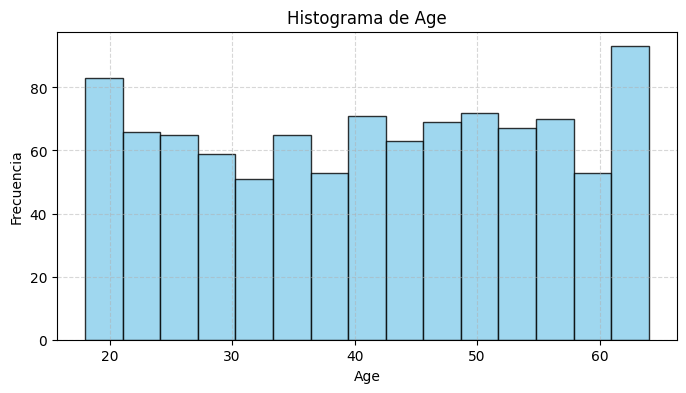

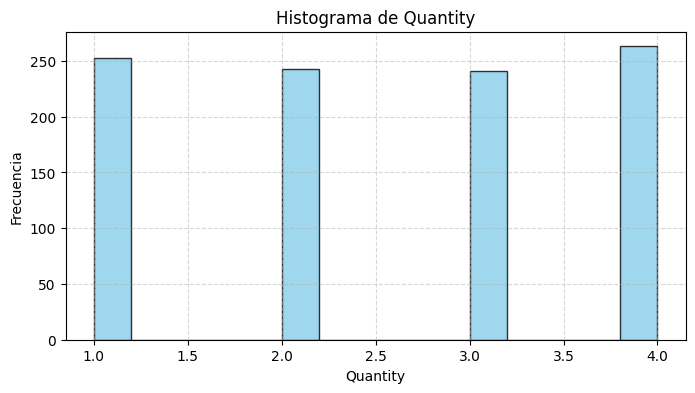

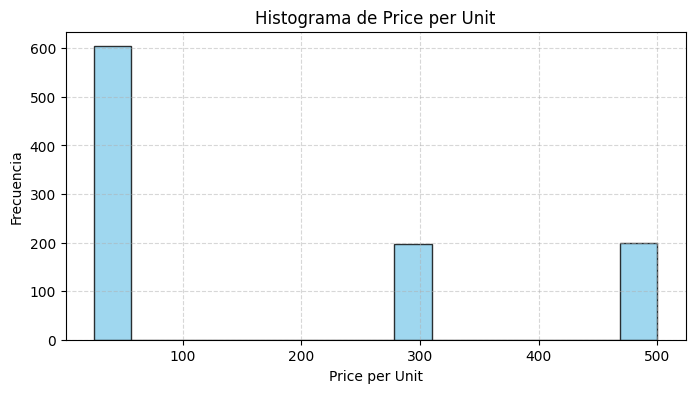

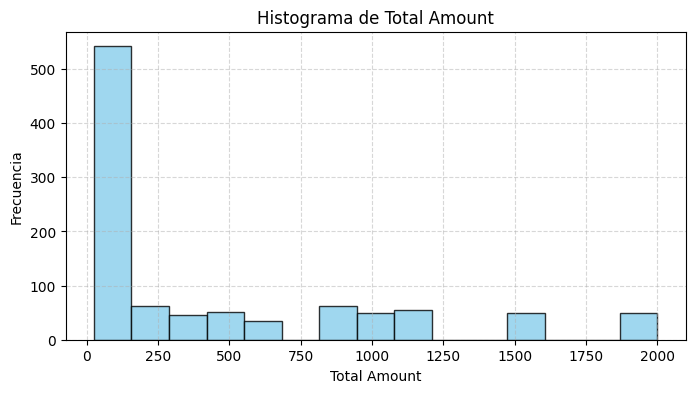

In [23]:
import matplotlib.pyplot as plt

# 2.2. Utiliza histogramas y boxplots para visualizar la distribución de las variables numéricas clave.
# Variables numéricas
variables = [
    'Age',
    'Quantity',
    'Price per Unit',
    'Total Amount'
]

# Histogramas
for col in variables:

    plt.figure(figsize=(8,4))

    plt.hist(
        df[col],
        bins=15,
        color='skyblue',
        edgecolor='black',
        alpha=0.8
    )

    plt.title(f'Histograma de {col}')

    plt.xlabel(col)

    plt.ylabel('Frecuencia')

    plt.grid(
        linestyle='--',
        alpha=0.5
    )

    plt.show()



Los histogramas permitieron identificar la distribución de las principales variables numéricas del dataset. Se observó que las edades de los clientes están distribuidas de forma relativamente equilibrada, mientras que las cantidades compradas se concentran en pocas unidades por compra.

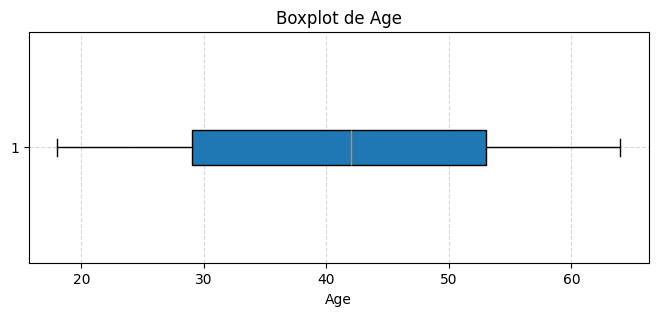

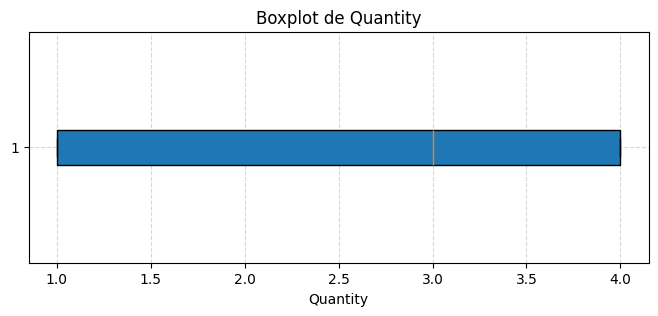

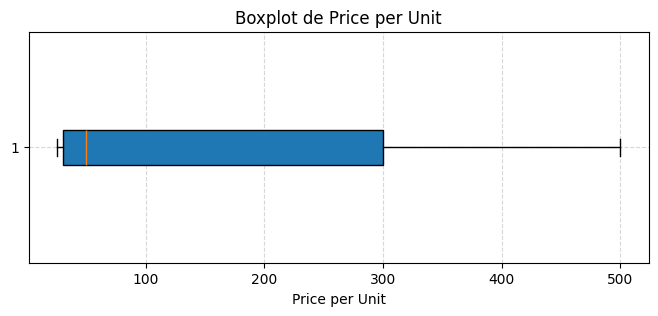

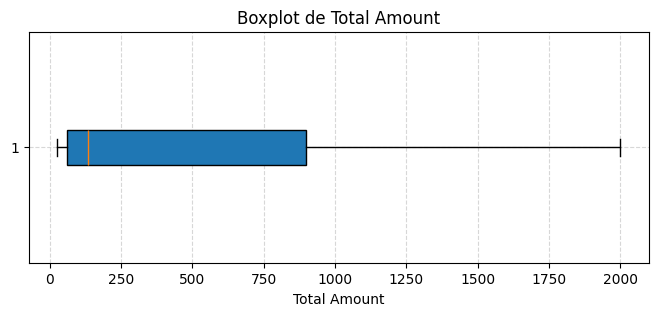

In [24]:
# 2.2. Boxplots
for col in variables:

    plt.figure(figsize=(8,3))

    plt.boxplot(
        df[col],
        vert=False,
        patch_artist=True
    )

    plt.title(f'Boxplot de {col}')

    plt.xlabel(col)

    plt.grid(
        linestyle='--',
        alpha=0.5
    )

    plt.show()


Al revisar la distribución de las cuatro variables numéricas del dataset, refleja un comercio con clientes de edad media, compras de pocas unidades, precios mayoritariamente bajos pero con productos premium, y montos totales que pueden variar bastante dependiendo del artículo adquirido.

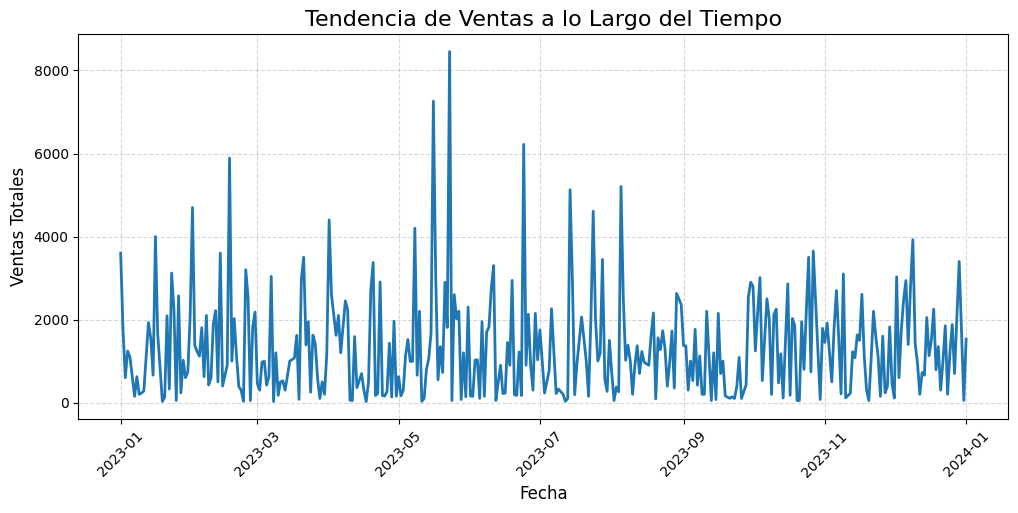

El gráfico de líneas muestra la evolución de las ventas a lo largo del tiempo e identificar tendencias, aumentos o disminuciones en las ventas.


In [25]:
# 2.3. Crear gráfico de líneas

# Convertir la fecha a formato datetime
df['Date'] = pd.to_datetime(df['Date'])

# Agrupar ventas por fecha
ventas_fecha = df.groupby(
    'Date'
)['Total Amount'].sum()

# Crear gráfico de líneas
plt.figure(figsize=(12,5))

plt.plot(
    ventas_fecha.index,
    ventas_fecha.values,
    linewidth=2
)

plt.title(
    'Tendencia de Ventas a lo Largo del Tiempo',
    fontsize=16
)

plt.xlabel(
    'Fecha',
    fontsize=12
)

plt.ylabel(
    'Ventas Totales',
    fontsize=12
)

plt.xticks(rotation=45)

plt.grid(
    linestyle='--',
    alpha=0.5
)

plt.show()
print('El gráfico de líneas muestra la evolución de las ventas a lo largo del tiempo e identificar tendencias, aumentos o disminuciones en las ventas.')


El negocio opera con una demanda irregular y puntual, lo que sugiere la necesidad de identificar los factores que generan los pic de venta para potenciarlos, y los que causan los valles para mitigarlos.

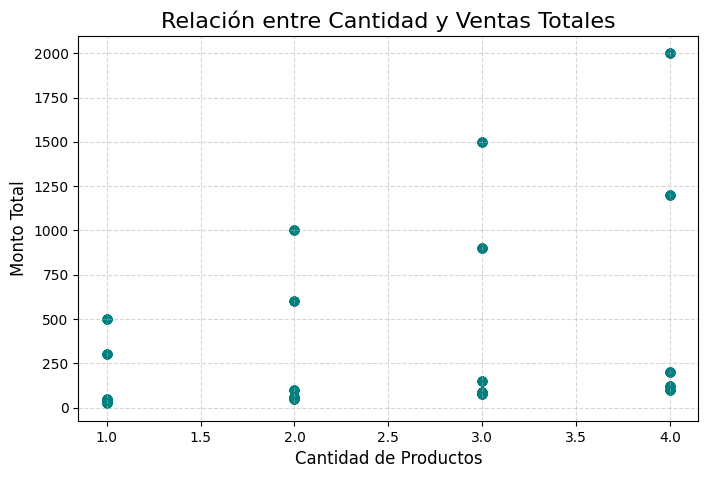

El gráfico de dispersión permite identificar la relación entre la cantidad de productos comprados y el monto total de la venta.


In [26]:
# 2.4. Gráfico de dispersión:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Quantity'],
    df['Total Amount'],
    alpha=0.6,
    color='teal'
)

plt.title(
    'Relación entre Cantidad y Ventas Totales',
    fontsize=16
)

plt.xlabel(
    'Cantidad de Productos',
    fontsize=12
)

plt.ylabel(
    'Monto Total',
    fontsize=12
)

plt.grid(
    linestyle='--',
    alpha=0.5
)

plt.show()
print('El gráfico de dispersión permite identificar la relación entre la cantidad de productos comprados y el monto total de la venta.')


La cantidad de productos comprados tiene poca influencia directa sobre el monto total. Para entender el gasto real de un cliente, es más relevante analizar qué producto compró que cuántas unidades adquirió.

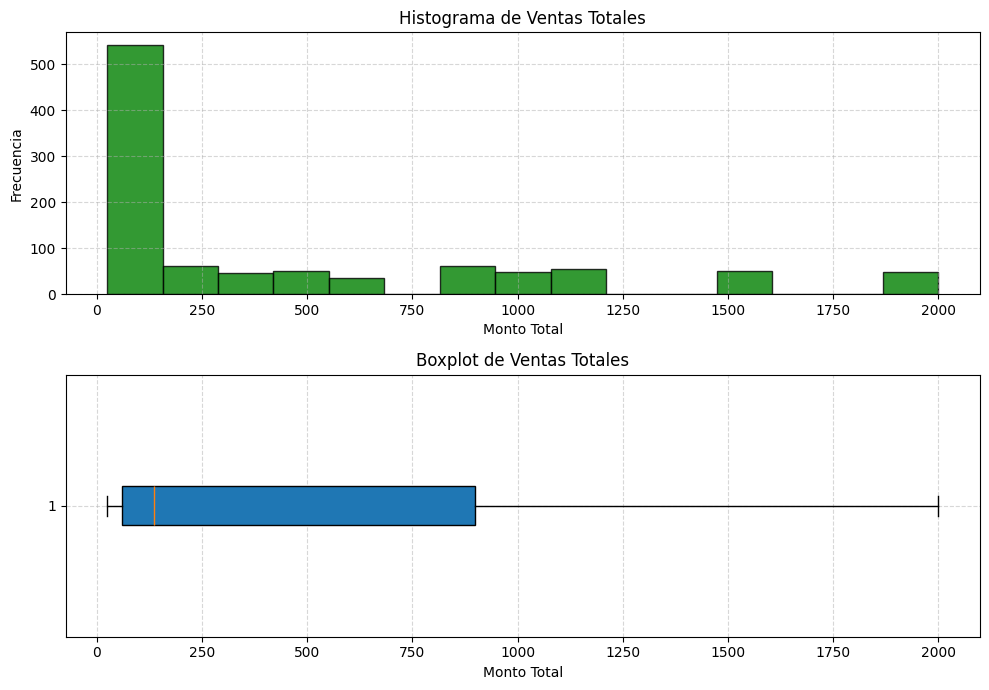

El histograma permite observar cómo se distribuyen las ventas totales, mientras que el boxplot facilita
la identificación de posibles valores atípicos y la dispersión de los datos.


In [27]:
# 2.5. Combina histogramas y boxplots para visualizar la distribución de las ventas y detectar valores atípicos.
# Crear figura
fig, axes = plt.subplots(
    2,
    1,
    figsize=(10,7)
)

# Histograma
axes[0].hist(
    df['Total Amount'],
    bins=15,
    color='green',
    edgecolor='black',
    alpha=0.8
)

axes[0].set_title(
    'Histograma de Ventas Totales'
)

axes[0].set_xlabel(
    'Monto Total'
)

axes[0].set_ylabel(
    'Frecuencia'
)

axes[0].grid(
    linestyle='--',
    alpha=0.5
)

# Boxplot
axes[1].boxplot(
    df['Total Amount'],
    vert=False,
    patch_artist=True
)

axes[1].set_title(
    'Boxplot de Ventas Totales'
)

axes[1].set_xlabel(
    'Monto Total'
)

axes[1].grid(
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()

plt.show()
print('El histograma permite observar cómo se distribuyen las ventas totales, mientras que el boxplot facilita')
print('la identificación de posibles valores atípicos y la dispersión de los datos.')


El negocio opera principalmente con transacciones de ticket bajo, pero mantiene una actividad constante de ventas de mayor valor que, aunque menos frecuentes, contribuyen significativamente al total acumulado. Esto sugiere que existe una segmentación natural entre clientes ocasionales de bajo gasto y clientes que adquieren productos premium.

**Proyecto 1- Parte final (Core)**

Proyecto 1: Análisis y Predicción de Ventas en una Tienda de Retail

**Parte 1: Exploración y Visualización de Datos (EDA)**

**1. Carga y Exploración Inicial de Datos:**

1.1. Cargar el dataset y revisar su estructura básica.

1.2. Describir las variables y su distribución.

1.3. Identificar y tratar valores nulos y outliers.

Realizado anteriormente

**2. Análisis de Correlación:**

2.1. Realizar un análisis de correlación y crear un mapa de calor para visualizar las relaciones entre las variables.

In [28]:
# Ver variables numéricas

df.select_dtypes(include=['int64','float64']).columns

Index(['Transaction ID', 'Age', 'Quantity', 'Price per Unit', 'Total Amount',
       'Ingreso_Total', 'Ventas_Normalizadas'],
      dtype='object')

In [29]:
# Calcular matriz de correlación

correlation_matrix = df.corr(numeric_only=True)

display(correlation_matrix)

,Transaction ID,Age,Quantity,Price per Unit,Total Amount,Ingreso_Total,Ventas_Normalizadas
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034,-0.075034,-0.075034
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568,-0.060568,-0.060568
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707,0.373707,0.373707
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925,0.851925,0.851925
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000,1.000000,1.000000
Ingreso_Total,-0.075034,-0.060568,0.373707,0.851925,1.000000,1.000000,1.000000
Ventas_Normalizadas,-0.075034,-0.060568,0.373707,0.851925,1.000000,1.000000,1.000000


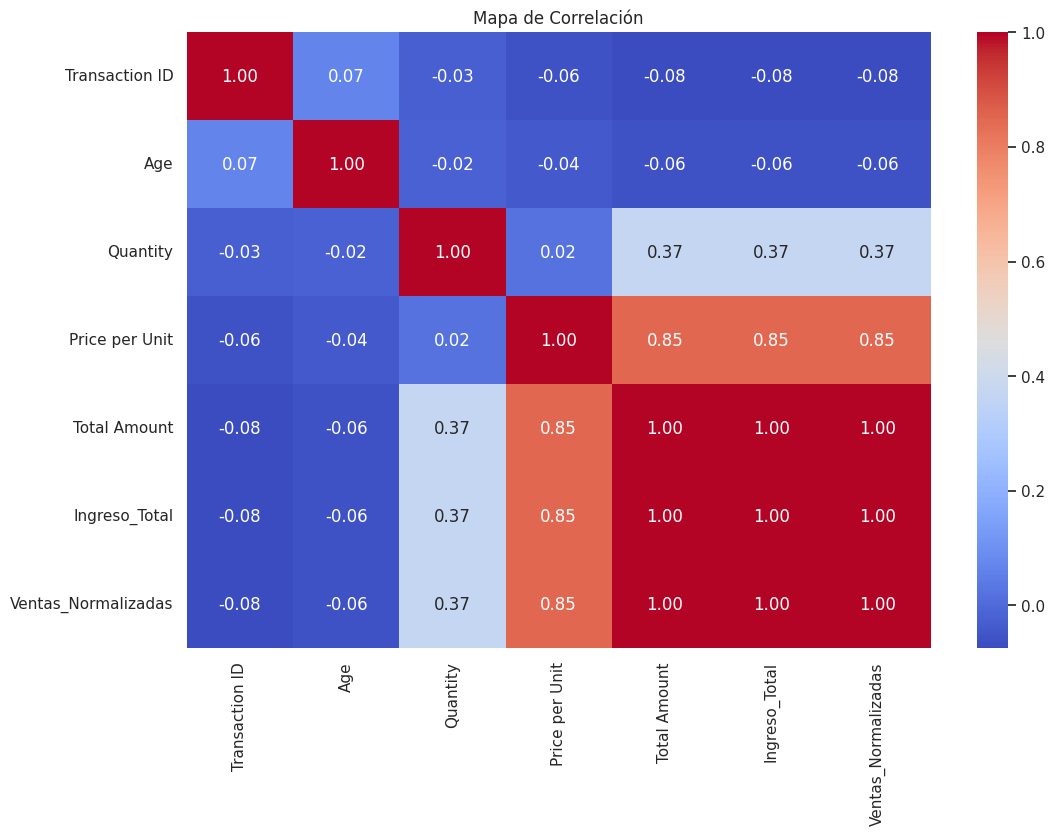

In [32]:
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Mapa de Correlación')

plt.show()

**3. Visualización de Datos:**

3.1. Crear subplots para comparar diferentes variables clave.

3.2. Añadir cuadrículas, leyendas, anotaciones y flechas a los gráficos para mejorar la claridad y la información.

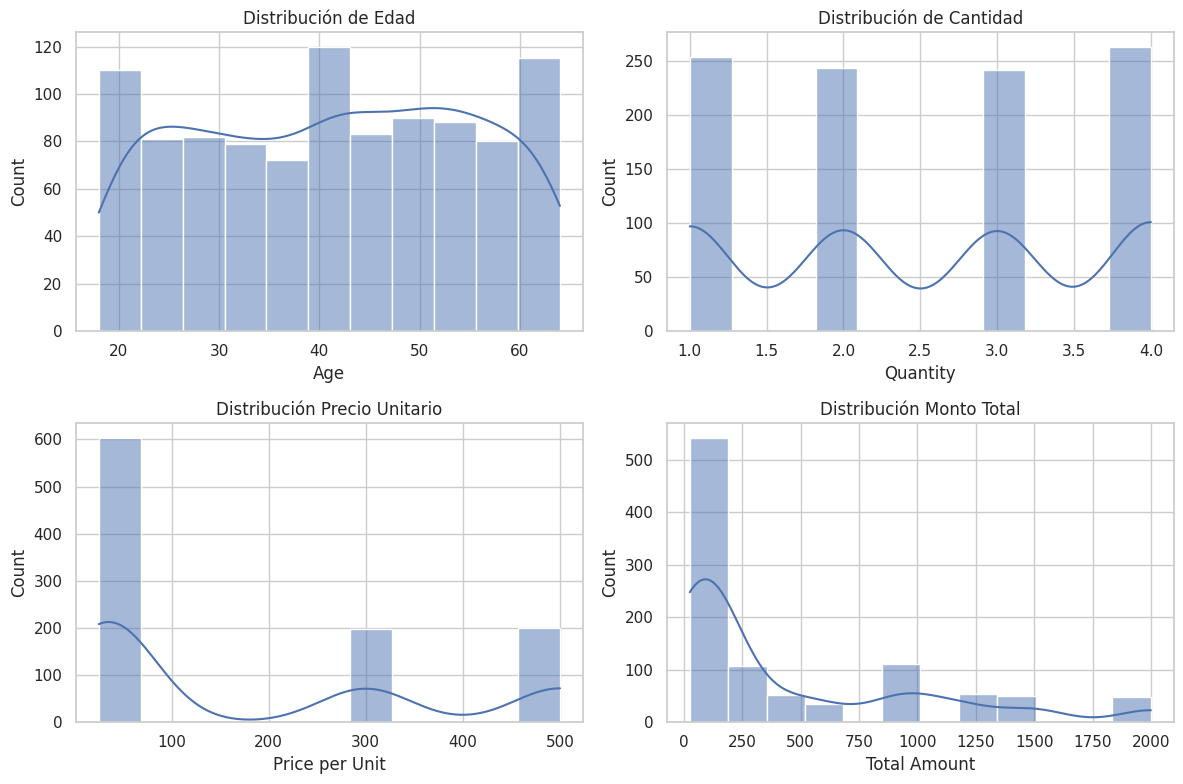

In [33]:
# 3.1. Crear subplots para comparar diferentes variables clave
# Distribución de Edad, Cantidad, Precio Unitario y Monto Total
fig, axes = plt.subplots(2, 2, figsize=(12,8))

sns.histplot(df['Age'], kde=True, ax=axes[0,0])
axes[0,0].set_title('Distribución de Edad')

sns.histplot(df['Quantity'], kde=True, ax=axes[0,1])
axes[0,1].set_title('Distribución de Cantidad')

sns.histplot(df['Price per Unit'], kde=True, ax=axes[1,0])
axes[1,0].set_title('Distribución Precio Unitario')

sns.histplot(df['Total Amount'], kde=True, ax=axes[1,1])
axes[1,1].set_title('Distribución Monto Total')

plt.tight_layout()
plt.show()

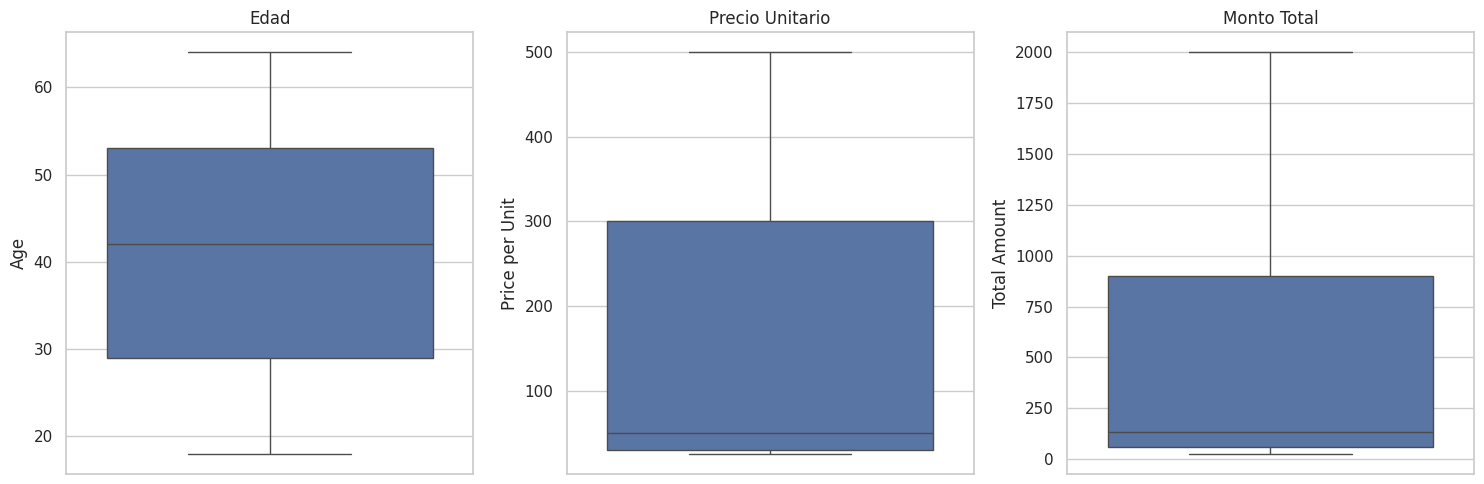

In [34]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.boxplot(y=df['Age'], ax=axes[0])
axes[0].set_title('Edad')

sns.boxplot(y=df['Price per Unit'], ax=axes[1])
axes[1].set_title('Precio Unitario')

sns.boxplot(y=df['Total Amount'], ax=axes[2])
axes[2].set_title('Monto Total')

plt.tight_layout()
plt.show()

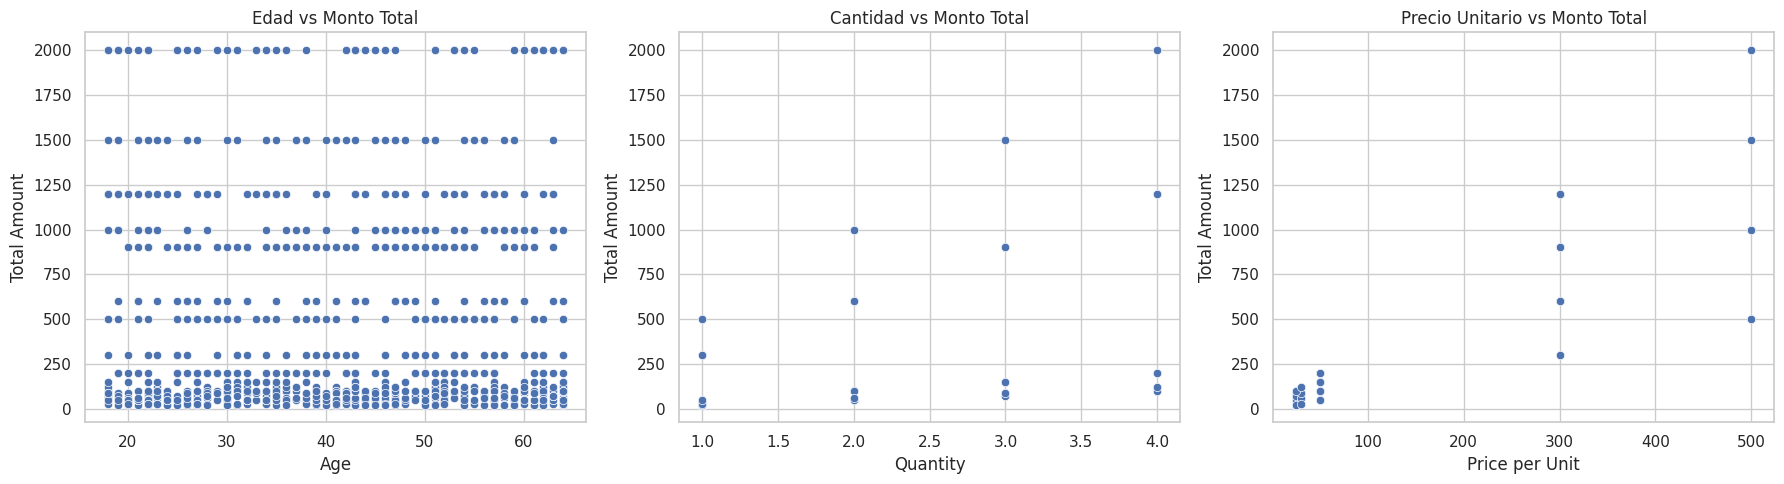

In [35]:
# Comparación de variables con el monto total
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.scatterplot(data=df,x='Age',y='Total Amount',ax=axes[0])
axes[0].set_title('Edad vs Monto Total')
sns.scatterplot(data=df,x='Quantity',y='Total Amount',ax=axes[1])
axes[1].set_title('Cantidad vs Monto Total')

sns.scatterplot(data=df,x='Price per Unit',y='Total Amount',ax=axes[2])
axes[2].set_title('Precio Unitario vs Monto Total')

plt.tight_layout()
plt.show()

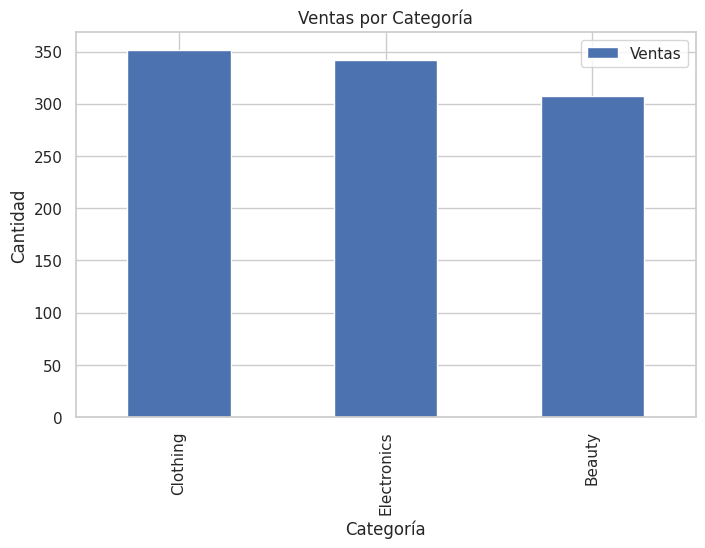

In [36]:
# 3.2. Añadir cuadrículas, leyendas, anotaciones y flechas
# Gráfico de ventas por categoría con cuadrícula

plt.figure(figsize=(8,5))
df['Product Category'].value_counts().plot(kind='bar',label='Ventas')
plt.title('Ventas por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Cantidad')
plt.legend()
plt.grid(True)

plt.show()

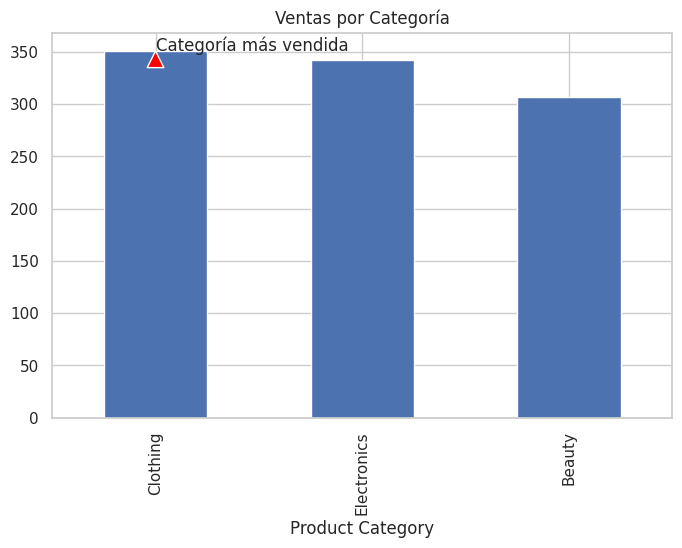

In [39]:
# Anotación del producto más vendido
ventas_categoria = df['Product Category'].value_counts()
plt.figure(figsize=(8,5))
ventas_categoria.plot(kind='bar')
plt.annotate('Categoría más vendida',xy=(0, ventas_categoria.max()),arrowprops=dict(facecolor='red'))
plt.title('Ventas por Categoría')
plt.grid(True)

plt.show()

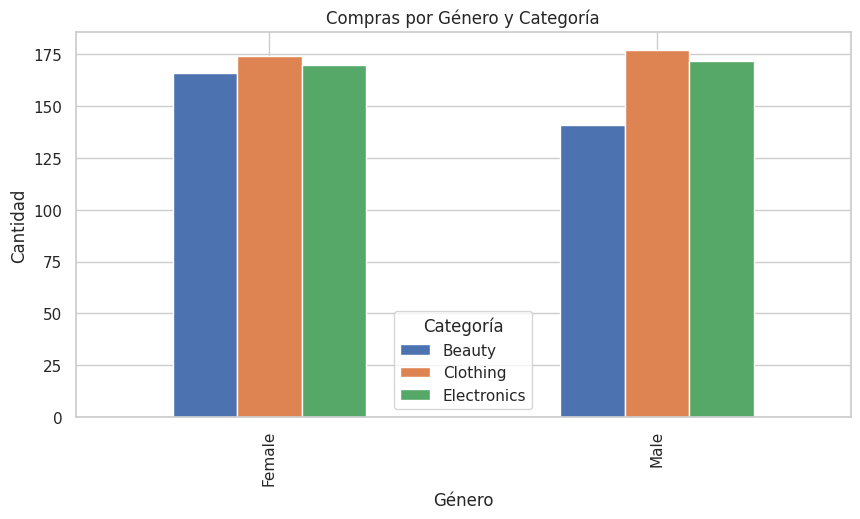

In [40]:
tabla = pd.crosstab(df['Gender'],df['Product Category'])

tabla.plot(kind='bar',figsize=(10,5))

plt.title('Compras por Género y Categoría')
plt.xlabel('Género')
plt.ylabel('Cantidad')
plt.grid(True)
plt.legend(title='Categoría')

plt.show()

A partir de los gráficos obtenidos, se observan varios patrones relevantes en el comportamiento de las ventas y los clientes.

Distribución de Edad: Los clientes presentan una distribución relativamente uniforme entre los 18 y 64 años, con una ligera concentración entre los 40 y 55 años. El boxplot confirma que no existen valores atípicos significativos en esta variable.

Cantidad de Productos Comprados: La mayoría de las transacciones corresponden a compras de entre 1 y 4 unidades, con una distribución bastante equilibrada entre las distintas cantidades disponibles.

Precio por Unidad: Se identifican tres niveles de precios claramente definidos (aproximadamente 50, 300 y 500 unidades monetarias), lo que sugiere la existencia de diferentes categorías o gamas de productos dentro del negocio.

Monto Total de Compra: La distribución presenta una fuerte asimetría positiva, donde predominan las compras de bajo monto y existe un grupo menor de transacciones de alto valor. El boxplot muestra una gran dispersión de los montos, aunque sin evidenciar outliers extremos.

Relación entre Variables y Ventas: La edad no parece tener una relación clara con el monto total gastado. En cambio, tanto la cantidad comprada como el precio unitario muestran una relación positiva con el monto total, lo que es consistente con la fórmula utilizada para calcular las ventas.

Ventas por Categoría: La categoría Clothing es la que registra la mayor cantidad de ventas, seguida muy de cerca por Electronics, mientras que Beauty presenta una participación ligeramente menor.

Compras por Género y Categoría: Se observa un comportamiento de compra bastante equilibrado entre hombres y mujeres. Las mujeres realizan más compras en la categoría Beauty, mientras que los hombres presentan una participación levemente superior en Clothing y Electronics, aunque las diferencias no son muy marcadas.

En general, los datos muestran una distribución balanceada de clientes y categorías, sin problemas evidentes de calidad de datos. Las variables Price per Unit, Quantity y Total Amount aparecen como las más relevantes para explicar el comportamiento de las ventas y serán candidatas importantes para análisis posteriores y construcción de modelos predictivos.

**Parte 2: Preprocesamiento de Datos**

**1. Transformación de Columnas:**

1.1. Utilizar ColumnTransformer para aplicar transformaciones específicas a diferentes columnas.

1.2. Realizar codificación de variables categóricas y escalado de variables numéricas.

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [42]:
# Separar variables predictoras y variable objetivo

X = df.drop(columns=['Categoria_Ventas'])
y = df['Categoria_Ventas']

In [43]:
# Definir columnas numéricas y categóricas

columnas_numericas = [
    'Age',
    'Quantity',
    'Price per Unit',
    'Total Amount',
    'Ingreso_Total',
    'Ventas_Normalizadas'
]

columnas_categoricas = [
    'Gender',
    'Product Category'
]

In [44]:
# Crear transformador

preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), columnas_numericas),('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)])

In [45]:
# Dividir datos

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [46]:
# Aplicar transformaciones

X_train_transformado = preprocessor.fit_transform(X_train)

X_test_transformado = preprocessor.transform(X_test)

In [47]:
# Ver dimensiones finales

print("X_train original:", X_train.shape)
print("X_train transformado:", X_train_transformado.shape)

print("X_test original:", X_test.shape)
print("X_test transformado:", X_test_transformado.shape)

X_train original: (800, 11)
X_train transformado: (800, 11)
X_test original: (200, 11)
X_test transformado: (200, 11)


**2. Pipelines:**

2.1. Crear pipelines para automatizar el preprocesamiento de datos y asegurar la reproducibilidad.


In [48]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [49]:
# Crear pipeline completo

pipeline_lr = Pipeline(steps=[('preprocessor', preprocessor),('modelo', LogisticRegression(max_iter=1000))])

In [50]:
# Entrenar pipeline

pipeline_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Quantity',
                                                   'Price per Unit',
                                                   'Total Amount',
                                                   'Ingreso_Total',
                                                   'Ventas_Normalizadas']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender',
                                                   'Product Category'])])),
                ('modelo', LogisticRegression(max_iter=1000))])

In [51]:
# Realizar predicciones

y_pred_lr = pipeline_lr.predict(X_test)

In [52]:
# Evaluar modelo

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Accuracy: 1.0
              precision    recall  f1-score   support

        Alta       1.00      1.00      1.00        61
        Baja       1.00      1.00      1.00        99
       Media       1.00      1.00      1.00        40

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



**Parte 3: Benchmarking de Técnicas de Machine Learning**

**1. Selección de Modelos:**

1.1. Entrenar y evaluar múltiples modelos de machine learning (por ejemplo, Regresión Lineal, KNN, Árbol de Decisión, Random Forest, XGBoost y LGBM).

1.2. Utilizar validación cruzada para evaluar el rendimiento de los modelos.


In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

In [54]:
# Regresión Logística
pipeline_lr = Pipeline([('preprocessor',preprocessor),('modelo',LogisticRegression(max_iter=1000))])
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
print('Accuracy LR:', acc_lr)

Accuracy LR: 1.0


In [55]:
# KNN
pipeline_knn = Pipeline([('preprocessor', preprocessor),('modelo', KNeighborsClassifier(n_neighbors=5))])
pipeline_knn.fit(X_train, y_train)
y_pred_knn = pipeline_knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
print('Accuracy KNN:', acc_knn)

Accuracy KNN: 0.925


In [56]:
# Árbol de Decisión
pipeline_tree = Pipeline([('preprocessor',preprocessor),('modelo', DecisionTreeClassifier(random_state=42))])
pipeline_tree.fit(X_train, y_train)
y_pred_tree = pipeline_tree.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)
print('Accuracy Árbol:', acc_tree)

Accuracy Árbol: 1.0


In [57]:
# Random Forest
pipeline_rf = Pipeline([('preprocessor',preprocessor),('modelo', RandomForestClassifier(random_state=42))])
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print('Accuracy RF:', acc_rf)

Accuracy RF: 1.0


In [58]:
# 1.2 Utilizar validación cruzada
# Regresión Logística
scores_lr = cross_val_score(pipeline_lr,X,y,cv=5,scoring='accuracy')
print(scores_lr.mean())

0.999


In [59]:
# KNN
scores_knn = cross_val_score(pipeline_knn,X,y,cv=5,scoring='accuracy')
print(scores_knn.mean())

0.942


In [60]:
# Árbol
scores_tree = cross_val_score(pipeline_tree,X,y,cv=5,scoring='accuracy')
print(scores_tree.mean())

1.0


In [62]:
# Random Forest
scores_rf = cross_val_score(pipeline_rf,X,y,cv=5,scoring='accuracy')

print(scores_rf.mean())

1.0


In [63]:
resultados = pd.DataFrame({'Modelo': ['Regresión Logística','KNN','Árbol de Decisión','Random Forest',],'Accuracy CV': [scores_lr.mean(),scores_knn.mean(),scores_tree.mean(),scores_rf.mean(),]})

resultados = resultados.sort_values(by='Accuracy CV',ascending=False)

display(resultados)

,Modelo,Accuracy CV
3,Random Forest,1.000
2,Árbol de Decisión,1.000
0,Regresión Logística,0.999
1,KNN,0.942


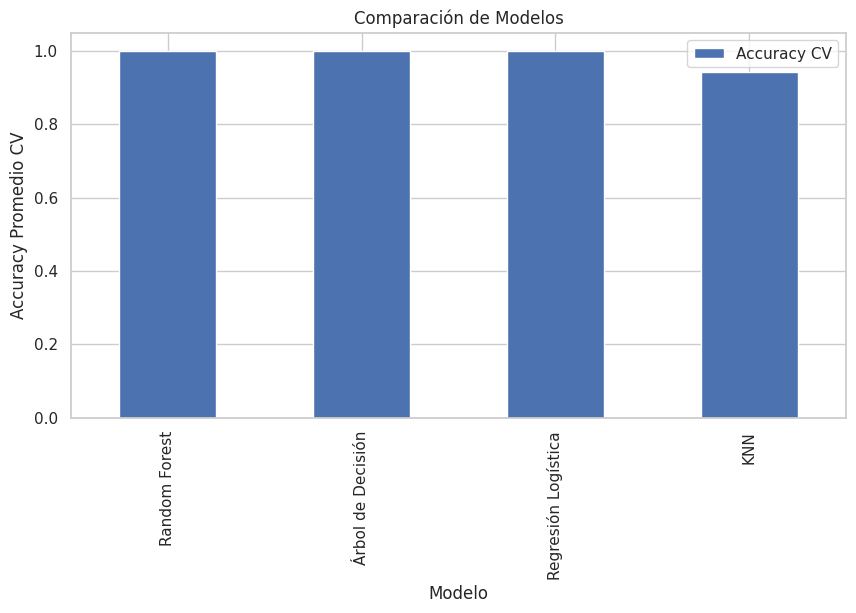

In [64]:
resultados.plot(x='Modelo',y='Accuracy CV',kind='bar',figsize=(10,5))
plt.title('Comparación de Modelos')
plt.ylabel('Accuracy Promedio CV')
plt.grid(True)

plt.show()

**2. Comparación de Modelos:**

2.1. Comparar los modelos utilizando métricas de rendimiento como exactitud, precisión, recall, F1-Score y ROC-AUC.

2.2. Seleccionar el mejor modelo basado en las métricas obtenidas.

In [78]:
# 2.1. Comparar los modelos utilizando métricas de rendimiento como exactitud, precisión, recall, F1-Score y ROC-AUC.
resultados = pd.DataFrame({'Modelo': [
        'Regresión Logística',
        'KNN',
        'Árbol de Decisión',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],

    'Precision': [
        precision_score(y_test, y_pred_lr, average='weighted'),
        precision_score(y_test, y_pred_knn, average='weighted'),
        precision_score(y_test, y_pred_tree, average='weighted'),
        precision_score(y_test, y_pred_rf, average='weighted')
    ],

    'Recall': [
        recall_score(y_test, y_pred_lr, average='weighted'),
        recall_score(y_test, y_pred_knn, average='weighted'),
        recall_score(y_test, y_pred_tree, average='weighted'),
        recall_score(y_test, y_pred_rf, average='weighted')
    ],

    'F1-Score': [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_knn, average='weighted'),
        f1_score(y_test, y_pred_tree, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted')
    ]})

display(resultados)

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Regresión Logística,1.000,1.000000,1.000,1.000000
1,KNN,0.925,0.925645,0.925,0.921877
2,Árbol de Decisión,1.000,1.000000,1.000,1.000000
3,Random Forest,1.000,1.000000,1.000,1.000000


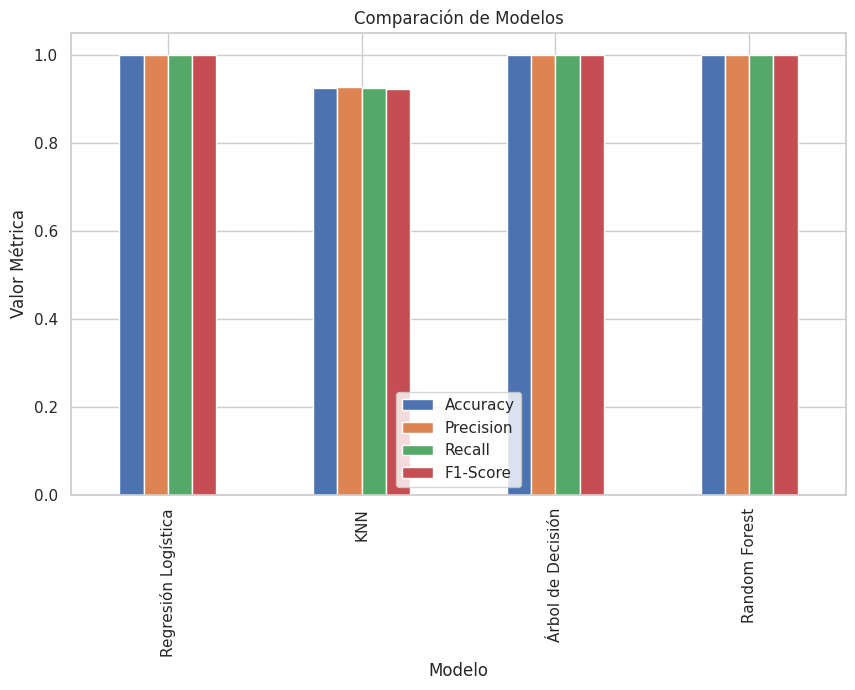

In [76]:
resultados.set_index('Modelo').plot(kind='bar',figsize=(10,6))

plt.title('Comparación de Modelos')
plt.ylabel('Valor Métrica')
plt.grid(True)

plt.show()

In [73]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred_rf)
print(cm)

[[61  0  0]
 [ 0 99  0]
 [ 0  0 40]]


In [77]:
display(resultados)

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Regresión Logística,1.000,1.000000,1.000,1.000000
1,KNN,0.925,0.925645,0.925,0.921877
2,Árbol de Decisión,1.000,1.000000,1.000,1.000000
3,Random Forest,1.000,1.000000,1.000,1.000000


2.2. Seleccionar el mejor modelo basado en las métricas obtenidas.

Al comparar los modelos, Regresión Logística, Árbol de Decisión y Random Forest obtuvieron un desempeño perfecto, con valores de Accuracy, Precision, Recall y F1-Score iguales a 1.00. Esto indica que los modelos clasificaron correctamente todos los casos del conjunto de prueba. Por otro lado, KNN también mostró un buen rendimiento, aunque menor, con un Accuracy de 92,5% y un F1-Score de 92,19%.

El mejor rendimiento lo obtuvieron Regresión Logística, Árbol de Decisión y Random Forest. Sin embargo, métricas perfectas pueden ser una señal de que la variable objetivo está demasiado relacionada con alguna variable predictora, especialmente si Categoria_Ventas fue creada a partir de Total Amount, Ingreso_Total o Ventas_Normalizadas. En ese caso, el modelo no estaría aprendiendo un patrón real, sino reutilizando información directa de la variable objetivo.

**Parte 4: Análisis de Métricas**

**1. Informe de Clasificación:**

1.1. Generar un informe de clasificación para los modelos evaluados.

1.2. Incluir la matriz de confusión para una comprensión detallada de los errores de clasificación.


In [79]:
# 1.1. Generar un informe de clasificación
from sklearn.metrics import classification_report

In [69]:
from sklearn.metrics import classification_report

print('REGRESIÓN LOGÍSTICA')
print(classification_report(y_test, y_pred_lr))

REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

        Alta       1.00      1.00      1.00        61
        Baja       1.00      1.00      1.00        99
       Media       1.00      1.00      1.00        40

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [70]:
print('KNN')
print(classification_report(y_test, y_pred_knn))

KNN
              precision    recall  f1-score   support

        Alta       1.00      1.00      1.00        61
        Baja       0.89      0.97      0.93        99
       Media       0.90      0.70      0.79        40

    accuracy                           0.93       200
   macro avg       0.93      0.89      0.91       200
weighted avg       0.93      0.93      0.92       200



In [71]:
print('ÁRBOL DE DECISIÓN')
print(classification_report(y_test, y_pred_tree))

ÁRBOL DE DECISIÓN
              precision    recall  f1-score   support

        Alta       1.00      1.00      1.00        61
        Baja       1.00      1.00      1.00        99
       Media       1.00      1.00      1.00        40

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [72]:
print('RANDOM FOREST')
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST
              precision    recall  f1-score   support

        Alta       1.00      1.00      1.00        61
        Baja       1.00      1.00      1.00        99
       Media       1.00      1.00      1.00        40

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



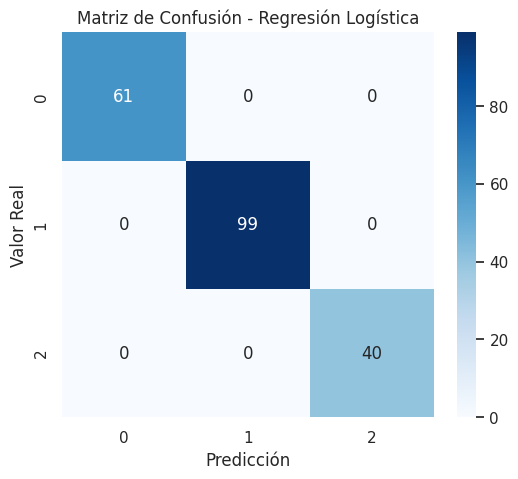

In [84]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')

plt.show()

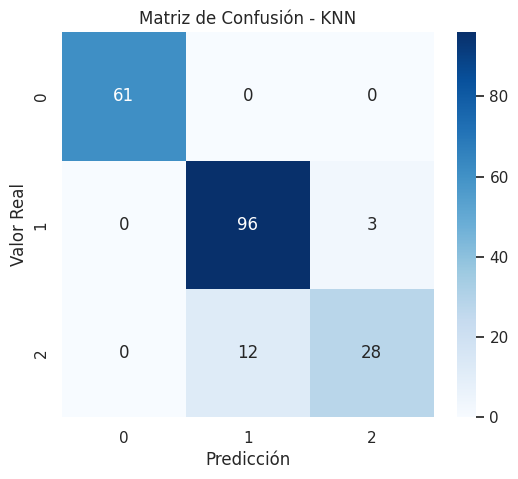

In [82]:
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusión - KNN')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')

plt.show()

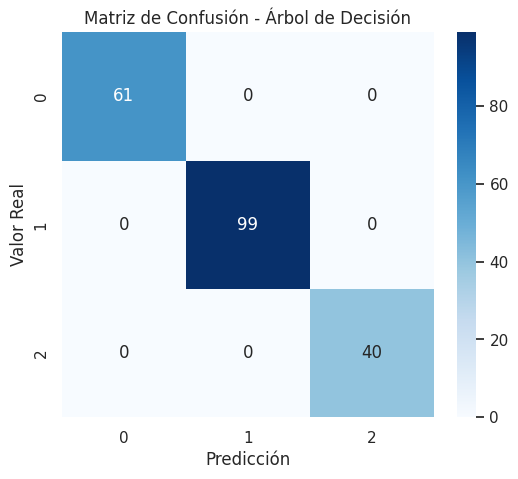

In [83]:
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusión - Árbol de Decisión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')

plt.show()

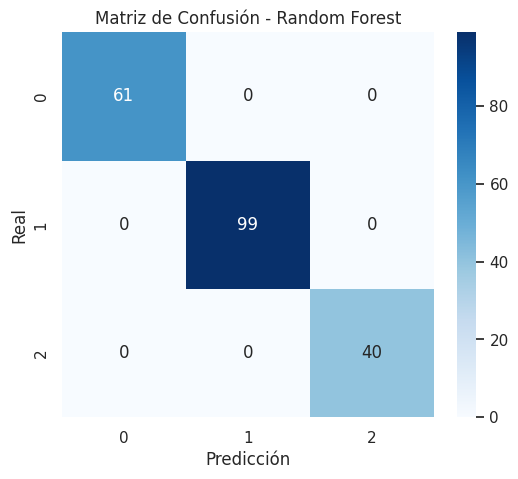

In [75]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues')

plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Real')

plt.show()

**2. Curva ROC y AUC:**

2.1. Crear y visualizar la curva ROC para los modelos de clasificación binaria.

2.2. Calcular el AUC para evaluar la capacidad del modelo para distinguir entre clases.

In [85]:
print(y.nunique())

3


La Curva ROC y el AUC son métricas diseñadas principalmente para problemas de clasificación binaria. Debido a que la variable objetivo del presente estudio contiene tres categorías, la evaluación de los modelos se realizó mediante Accuracy, Precision, Recall, F1-Score y Matriz de Confusión, métricas más adecuadas para problemas multiclase.